In [ ]:
from amoc_analysis import data, plotting
import amocatlas
from amocatlas import read

In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# Read OSNAP dataset

In [2]:
ds = read.osnap()

Loading 1 OSNAP dataset(s):
  0. OSNAP_MOC_MHT_MFT_TimeSeries_201408_202207_2025.nc: Time series of MOC, MHT, and MFT (2014-2022)



In [3]:
ds

<xarray.Dataset> Size: 15kB
Dimensions:              (TIME: 96)
Coordinates:
  * TIME                 (TIME) datetime64[ns] 768B 2014-08-01T12:00:00 ... 2...
Data variables: (12/18)
    MOC_SIGMA0           (TIME) float64 768B ...
    MOC_SIGMA0_ERR       (TIME) float64 768B ...
    MOC_EAST_SIGMA0      (TIME) float64 768B ...
    MOC_EAST_SIGMA0_ERR  (TIME) float64 768B ...
    MOC_WEST_SIGMA0      (TIME) float64 768B ...
    MOC_WEST_SIGMA0_ERR  (TIME) float64 768B ...
    ...                   ...
    MFT                  (TIME) float64 768B ...
    MFT_ERR              (TIME) float64 768B ...
    MFT_EAST             (TIME) float64 768B ...
    MFT_EAST_ERR         (TIME) float64 768B ...
    MFT_WEST             (TIME) float64 768B ...
    MFT_WEST_ERR         (TIME) float64 768B ...
Attributes: (12/40)
    title:                                 OSNAP MOC MHT MFT time series (201...
    summary:                               OSNAP transport and hydrographic e...
    description:                           OSNAP transport and hydrographic e...
    program:                               OSNAP
    project:                               Overturning in the Subpolar North ...
    license:                               CC-BY-4.0
    ...                                    ...
    processing_datasource:                 osnap55n
    variable_mapping:                      {'MOC_ALL': 'MOC_SIGMA0', 'MOC_WES...
    original_variable_metadata:            {'TIME': {'long_name': 'Start date...
    applied_variable_mapping:              {'MOC_ALL': 'MOC_SIGMA0', 'MOC_WES...
    files:                                 {'OSNAP_MOC_MHT_MFT_TimeSeries_201...
    data_assembly_center:                  Georgia Institute of Technology

## Explore dataset

### MOC of OSNAP EAST 

In [11]:
moc = ds["MOC_EAST_SIGMA0"]

In [39]:
shape = moc.shape
timemin = moc.TIME[0].values
timemax = moc.TIME[-1].values
time2 = moc.TIME[1].values
print(timemin, time2, timemax)

2014-08-01T12:00:00.000000000 2014-09-01T12:00:00.000000000 2022-07-01T12:00:00.000000000


- We see that the timeseries starts at 2014-08-01T12:00 and ends in 2022-07-01T12:00. 
- This means we have a record length of exactly 7 years and 11 months.
- We have a monthly resolution, which can be seen when comparing the moc.TIME[0] and moc.TIME[1] values. 
- The sample is always given at the first day of the month at 12pm. 


In [51]:
# missing values
moc_masked = moc.where(np.isnan(moc))
moc_large = moc.where(moc > 1e6)
print(moc_masked.sum().values)
print(moc_large.sum().values)

0.0
0.0


- we see no missing values (none are marked as nan). 
- also we have no incredibly large values which could have been used as filler values.
- therefore we do not need any interpolation/ gap-handling.
- if there would be a gap i would probably do some form of linear interpolation.

In [63]:
# mean, std, range
moc_mean = moc.mean().values
moc_median = moc.median().values
moc_std = moc.std().values
moc_min = moc.min().values
moc_max = moc.max().values
print(f"Mean: {moc_mean:2.3f} Sv")
print(f"Median: {moc_median:2.3f} Sv")
print(f"Standard Deviation: {moc_std:2.3f} Sv")
print(f"Min: {moc_min:2.3f} Sv")
print(f"Max: {moc_max:2.3f} Sv")

Mean: 16.351 Sv
Median: 16.191 Sv
Standard Deviation: 2.892 Sv
Min: 10.359 Sv
Max: 23.659 Sv


In [ ]:
moc_min.time

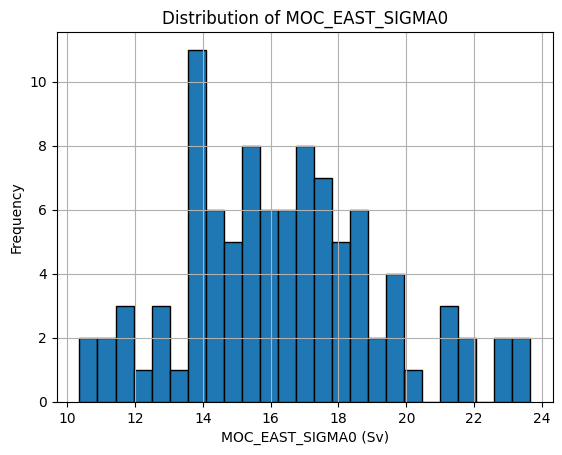

In [ ]:
# plot histogram of distribution
plt.hist(moc.values.flatten(), bins=25, edgecolor="black")
plt.title("Distribution of MOC_EAST_SIGMA0")
plt.xlabel("MOC_EAST_SIGMA0 (Sv)")
plt.ylabel("Frequency")
plt.grid()
plt.savefig("figures/osnap_east_histogram.png", dpi=300)

- we see it is actually kind of normally distributed (i am a little surprised).
- there are many values which lie in the 14 Sv bin, which is probably why the mean is at ~16 Sv, although we have so many high values. 
- interestingly there are no measurements which fall into the 20 or 22 Sv bin, which makes the histrogam appear discontinued. (do not know if this is the right word)
